Valley Fever Patient Clustering

Clustering synthetic Valley Fever patients with K-Prototypes, using both symptoms and social factors. 

#1. The Data

A quick look at the synthetic patient dataset before doing anything fancier.

In [1]:
# Imports plus the project's own pipeline code
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

from preprocess import preprocess
from cluster import find_best_k, fit_final_model
from evaluate import compute_silhouette_scores, cluster_profiles

# same color per cluster everywhere
CLUSTER_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]
STATUS_GOOD, STATUS_WARN, STATUS_CRIT = "#0ca30c", "#fab219", "#d03b3b"

# chart styling used throughout
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#52514e",
    "text.color": "#0b0b0b",
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "grid.color": "#e1e0d9",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [2]:
df = pd.read_csv("synthetic_patients.csv")
print(f"{len(df)} synthetic patients, {df.shape[1]} columns")
df.head()

200 synthetic patients, 15 columns


,patient_id,respiratory_severity,fatigue_level,fever_present,joint_pain,erythema_nodosum,symptom_duration_days,prior_misdiagnosis_count,housing_stability,employment_status,education_level,social_support_score,insurance_status,distance_to_clinic_miles,ground_truth_archetype
0,SYN-0001,1,1,False,1,False,6,1,stable,employed_indoor,bachelors_plus,6,insured,2.8,stable_well_managed
1,SYN-0002,3,2,False,2,False,48,1,unstable,unemployed,some_college,4,underinsured,13.6,delayed_diagnosis_vulnerable
2,SYN-0003,3,1,False,0,False,7,0,at_risk,employed_outdoor,hs_grad,2,uninsured,41.0,delayed_diagnosis_vulnerable
3,SYN-0004,2,1,True,3,False,3,0,stable,employed_outdoor,some_college,6,underinsured,18.8,young_acute_high_exposure
4,SYN-0005,1,3,True,2,False,48,2,stable,retired,bachelors_plus,4,insured,4.4,elderly_moderate_risk


In [3]:
# Quick stats on the numeric columns
df.describe()

,respiratory_severity,fatigue_level,joint_pain,symptom_duration_days,prior_misdiagnosis_count,social_support_score,distance_to_clinic_miles
count,200.000000,200.0000,200.000000,200.00000,200.000000,200.0000,200.000000
mean,1.580000,1.6700,1.255000,21.28500,0.815000,5.5650,13.923000
std,0.968654,0.8746,0.814427,20.58403,0.946177,2.4114,11.766167
min,0.000000,0.0000,0.000000,3.00000,0.000000,0.0000,1.000000
25%,1.000000,1.0000,1.000000,7.00000,0.000000,4.0000,6.400000
50%,2.000000,2.0000,1.000000,14.00000,1.000000,5.0000,9.900000
75%,2.000000,2.0000,2.000000,28.00000,1.000000,7.0000,17.550000
max,3.000000,3.0000,3.000000,120.00000,3.000000,10.0000,60.000000


In [4]:
# Housing and insurance -- the two SDOH columns most tied to delayed diagnosis
print("Housing stability:")
print(df["housing_stability"].value_counts(), "\n")

print("Insurance status:")
print(df["insurance_status"].value_counts())

Housing stability:
housing_stability
stable      122
at_risk      50
unstable     28
Name: count, dtype: int64 

Insurance status:
insurance_status
insured         110
underinsured     64
uninsured        26
Name: count, dtype: int64


2. Choosing k: Elbow Curve + Silhouette Score

We use both an elbow curve and silhouette score to pick k, and go with silhouette when they disagree 

In [5]:
processed_df, categorical_indices, scaler = preprocess()
matrix = processed_df.to_numpy()

k_range = range(2, 8)
costs = find_best_k(matrix, categorical_indices, k_range=k_range)
scores = compute_silhouette_scores(matrix, categorical_indices, k_range=k_range)

best_k = max(scores, key=lambda pair: pair[1])[0]
print("Elbow costs:      ", costs)
print("Silhouette scores:", scores)
print(f"\nChosen k (best silhouette score): {best_k}")

Elbow costs:       [(2, np.float64(1352.829928257435)), (3, np.float64(1190.0910155638585)), (4, np.float64(1061.0164508719192)), (5, np.float64(978.7255893663871)), (6, np.float64(922.762081912488)), (7, np.float64(880.6953586377008))]
Silhouette scores: [(2, np.float64(0.2661457515561979)), (3, np.float64(0.2449961114931777)), (4, np.float64(0.27233879526498334)), (5, np.float64(0.2868726073735995)), (6, np.float64(0.29699946392982113)), (7, np.float64(0.2851851341369224))]

Chosen k (best silhouette score): 6


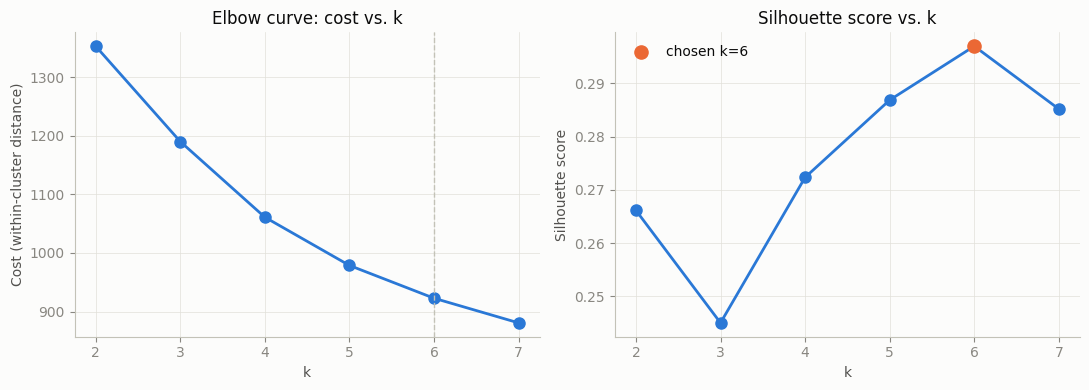

In [6]:
ks = [k for k, _ in costs]
cost_vals = [c for _, c in costs]
score_vals = [s for _, s in scores]
score_by_k = dict(scores)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(ks, cost_vals, color=CLUSTER_COLORS[0], linewidth=2, marker="o", markersize=8)
axes[0].axvline(best_k, color="#c3c2b7", linestyle="--", linewidth=1)
axes[0].set_title("Elbow curve: cost vs. k")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Cost (within-cluster distance)")
axes[0].grid(True, linewidth=0.5)

axes[1].plot(ks, score_vals, color=CLUSTER_COLORS[0], linewidth=2, marker="o", markersize=8)
axes[1].scatter([best_k], [score_by_k[best_k]], color=CLUSTER_COLORS[1], s=90,
                zorder=5, label=f"chosen k={best_k}")
axes[1].set_title("Silhouette score vs. k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette score")
axes[1].grid(True, linewidth=0.5)
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

We land on k = 6. Silhouette score peaks at k=6 (~0.297). 

 3. Fitting the Final Model

Fit K-Prototypes with the chosen k and check cluster sizes look reasonable.

0    41
1    23
2    10
3    48
4    51
5    27
Name: count, dtype: int64


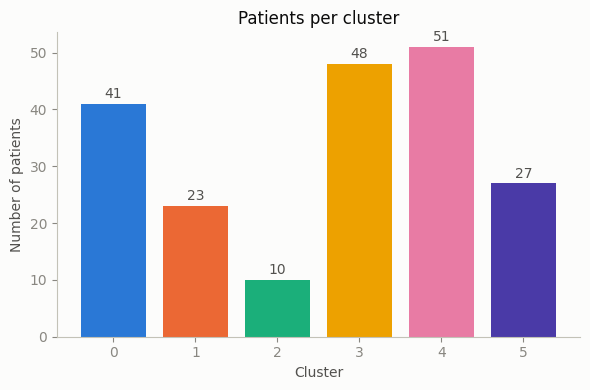

In [7]:
model, labels = fit_final_model(matrix, categorical_indices, best_k)

cluster_sizes = pd.Series(labels).value_counts().sort_index()
print(cluster_sizes)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(cluster_sizes.index.astype(str), cluster_sizes.values,
               color=CLUSTER_COLORS[:len(cluster_sizes)])
for bar, val in zip(bars, cluster_sizes.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 1, str(val), ha="center", color="#52514e")
ax.set_xlabel("Cluster")
ax.set_ylabel("Number of patients")
ax.set_title("Patients per cluster")
plt.tight_layout()
plt.show()

 Recovery metrics and patient-level uncertainty

ARI/NMI check recovery of the synthetic archetypes (not real-world validity), and silhouette_samples flags borderline patients. See README.md for more.

In [8]:
ground_truth = pd.read_csv("synthetic_patients.csv")["ground_truth_archetype"]

ari = adjusted_rand_score(ground_truth, labels)
nmi = normalized_mutual_info_score(ground_truth, labels)
print(f"Adjusted Rand Index vs. ground_truth_archetype: {ari:.4f}")
print(f"Normalized Mutual Info vs. ground_truth_archetype: {nmi:.4f}")

# pulled from evaluate.py's saved output, not recomputed here
clustered_df = pd.read_csv("clustered_patients.csv")
n_uncertain = clustered_df["uncertain"].sum()
pct_uncertain = 100 * n_uncertain / len(clustered_df)
print(f"\nPatients flagged uncertain/borderline: {n_uncertain} / {len(clustered_df)} ({pct_uncertain:.1f}%)")

Adjusted Rand Index vs. ground_truth_archetype: 0.4336
Normalized Mutual Info vs. ground_truth_archetype: 0.4339

Patients flagged uncertain/borderline: 22 / 200 (11.0%)


4. What Do the Clusters Actually Look Like?

Translating cluster numbers back into real, human-readable terms.

In [9]:
# original_df keeps real units, not scaled/z-score, for a readable profile table
original_df = pd.read_csv("synthetic_patients.csv").drop(columns=["patient_id"])

profile_df = cluster_profiles(processed_df, labels, original_df)
profile_df

,n_patients,respiratory_severity,fatigue_level,joint_pain,symptom_duration_days,prior_misdiagnosis_count,social_support_score,distance_to_clinic_miles,fever_present,erythema_nodosum,housing_stability,employment_status,education_level,insurance_status
cluster_label,,,,,,,,,,,,,,
0,41,1.243902,1.829268,2.000000,18.097561,0.634146,3.243902,14.746341,0.536585,0.073171,stable,retired,less_than_hs,insured
1,23,1.913043,1.739130,1.434783,62.130435,1.391304,4.000000,16.656522,0.565217,0.130435,at_risk,unemployed,hs_grad,underinsured
2,10,2.600000,2.400000,1.000000,31.900000,1.700000,4.900000,50.560000,0.600000,0.000000,at_risk,employed_outdoor,hs_grad,uninsured
3,48,0.541667,0.666667,0.750000,9.562500,0.312500,7.479167,8.539583,0.270833,0.041667,stable,employed_indoor,bachelors_plus,insured
4,51,2.333333,2.098039,1.137255,14.470588,0.176471,6.607843,11.888235,0.686275,0.078431,stable,employed_outdoor,hs_grad,insured
5,27,1.851852,2.074074,1.185185,21.111111,2.370370,5.296296,10.188889,0.666667,0.111111,stable,employed_outdoor,hs_grad,insured


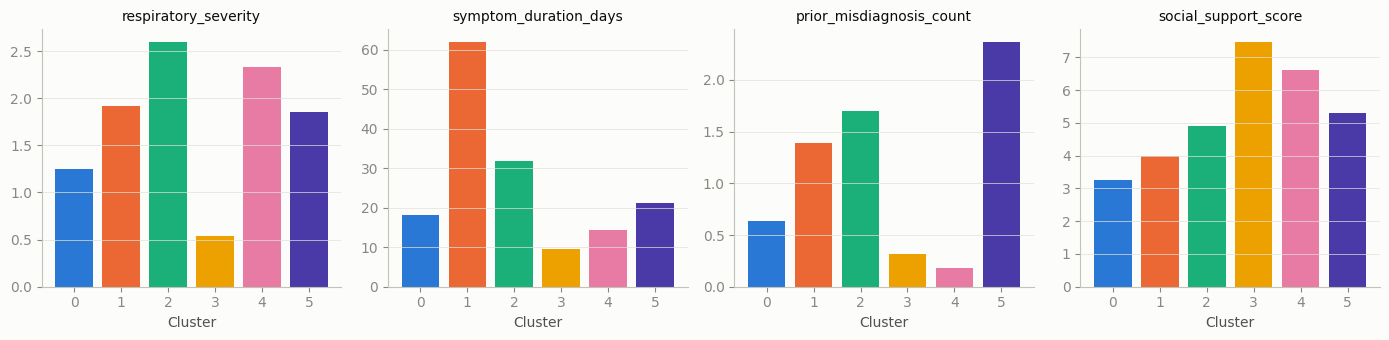

In [10]:
# small multiples so we're not mixing very different scales on one axis
numeric_features = ["respiratory_severity", "symptom_duration_days",
                     "prior_misdiagnosis_count", "social_support_score"]

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, feature in zip(axes, numeric_features):
    values = profile_df[feature]
    ax.bar(values.index.astype(str), values.values, color=CLUSTER_COLORS[:len(values)])
    ax.set_title(feature, fontsize=10)
    ax.set_xlabel("Cluster")
    ax.grid(True, axis="y", linewidth=0.5)

plt.tight_layout()
plt.show()

SDOH mix per cluster

Housing stability and insurance status are the clearest access-to-care signals in the data.

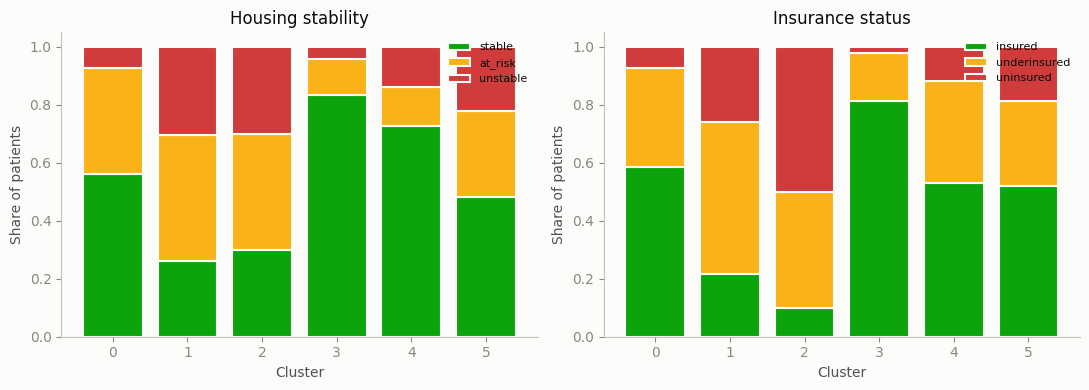

In [11]:
def stacked_proportions(df, cluster_col, category_col, category_order):
    """For each cluster, what fraction of patients fall in each category?"""
    counts = df.groupby(cluster_col)[category_col].value_counts(normalize=True).unstack(fill_value=0)
    return counts.reindex(columns=category_order, fill_value=0)

profile_source = original_df.copy()
profile_source["cluster_label"] = labels

housing_order = ["stable", "at_risk", "unstable"]
insurance_order = ["insured", "underinsured", "uninsured"]
status_colors = [STATUS_GOOD, STATUS_WARN, STATUS_CRIT]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, col, order, title in [
    (axes[0], "housing_stability", housing_order, "Housing stability"),
    (axes[1], "insurance_status", insurance_order, "Insurance status"),
]:
    props = stacked_proportions(profile_source, "cluster_label", col, order)
    bottom = np.zeros(len(props))
    for cat, color in zip(order, status_colors):
        ax.bar(props.index.astype(str), props[cat], bottom=bottom, color=color,
               edgecolor="#fcfcfb", linewidth=1.5, label=cat)
        bottom += props[cat].values
    ax.set_title(title)
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Share of patients")
    ax.legend(frameon=False, fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()

5. Sanity Check: Do Clusters Line Up With the Hidden Archetypes?

The generator built each patient around one of 4 archetypes, hidden from K-Prototypes. This checks if clusters rediscover them 

In [12]:
validation_df = pd.DataFrame({
    "cluster_label": labels,
    "ground_truth_archetype": original_df["ground_truth_archetype"].values,
})

crosstab_counts = pd.crosstab(validation_df["cluster_label"], validation_df["ground_truth_archetype"])
print("Counts:")
print(crosstab_counts)

crosstab_pct = pd.crosstab(validation_df["cluster_label"], validation_df["ground_truth_archetype"],
                            normalize="index").round(2)
print("\nShare of each cluster (rows sum to 1.0):")
print(crosstab_pct)

Counts:
ground_truth_archetype  delayed_diagnosis_vulnerable  elderly_moderate_risk  \
cluster_label                                                                 
0                                                  4                     30   
1                                                 16                      7   
2                                                  8                      1   
3                                                  0                      1   
4                                                  6                      3   
5                                                 11                      8   

ground_truth_archetype  stable_well_managed  young_acute_high_exposure  
cluster_label                                                           
0                                         1                          6  
1                                         0                          0  
2                                         0                        



Clusters 0, 3, and 4 line up well with elderly_moderate_risk, stable_well_managed, and young_acute_high_exposure. delayed_diagnosis_vulnerable splits across clusters 1, 2, and 5 instead of staying one group. See README.md for the full discussion, limitations, and what real EHR data would need.